# UniStock - Análise de Dados

## Disciplina 2: Análise de Dados (Python)

Projeto de análise de dados do sistema UniStock para tratamento de dados de estoque e vendas, cálculo de KPIs, estatísticas descritivas e visualizações analíticas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dados = {
    'Data': pd.date_range(start='2026-01-01', periods=20, freq='D'),
    'Produto': [
        'Nike Dunk', 'Jordan 1', 'Adidas Forum', 'Nike Air Max', 'Puma RS-X',
        'Nike Dunk', 'Jordan 1', 'Adidas Forum', 'Nike Air Max', 'Puma RS-X',
        'Nike Dunk', 'Jordan 1', 'Adidas Forum', 'Nike Air Max', 'Puma RS-X',
        'Nike Dunk', 'Jordan 1', 'Adidas Forum', 'Nike Air Max', 'Puma RS-X'
    ],
    'Categoria': [
        'Casual', 'Premium', 'Casual', 'Running', 'Running',
        'Casual', 'Premium', 'Casual', 'Running', 'Running',
        'Casual', 'Premium', 'Casual', 'Running', 'Running',
        'Casual', 'Premium', 'Casual', 'Running', 'Running'
    ],
    'Estoque_Inicial': [30,20,25,15,18,28,18,22,14,17,26,16,20,13,15,24,15,18,12,14],
    'Entradas': [10,5,8,6,4,12,4,7,5,6,8,6,5,4,5,10,7,6,5,4],
    'Saidas': [12,6,10,8,5,15,7,9,6,8,14,8,11,9,6,16,10,8,7,5],
    'Preco_Unitario': [799,1299,699,899,749,799,1299,699,899,749,799,1299,699,899,749,799,1299,699,899,749]
}

df = pd.DataFrame(dados)

df['Estoque_Final'] = df['Estoque_Inicial'] + df['Entradas'] - df['Saidas']
df['Receita'] = df['Saidas'] * df['Preco_Unitario']

df.head()

,Data,Produto,Categoria,Estoque_Inicial,Entradas,Saidas,Preco_Unitario,Estoque_Final,Receita
0,2026-01-01,Nike Dunk,Casual,30,10,12,799,28,9588
1,2026-01-02,Jordan 1,Premium,20,5,6,1299,19,7794
2,2026-01-03,Adidas Forum,Casual,25,8,10,699,23,6990
3,2026-01-04,Nike Air Max,Running,15,6,8,899,13,7192
4,2026-01-05,Puma RS-X,Running,18,4,5,749,17,3745


## 2.1 Tratamento de Dados (ETL) e KPIs

Nesta etapa será realizada a verificação e limpeza dos dados, além do cálculo dos principais indicadores de desempenho do projeto UniStock.

In [3]:
# Verificação inicial dos dados
print("Informações do dataset:")
print(df.info())

print("\nValores nulos por coluna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Data             20 non-null     datetime64[ns]
 1   Produto          20 non-null     object        
 2   Categoria        20 non-null     object        
 3   Estoque_Inicial  20 non-null     int64         
 4   Entradas         20 non-null     int64         
 5   Saidas           20 non-null     int64         
 6   Preco_Unitario   20 non-null     int64         
 7   Estoque_Final    20 non-null     int64         
 8   Receita          20 non-null     int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 1.5+ KB
None

Valores nulos por coluna:
Data               0
Produto            0
Categoria          0
Estoque_Inicial    0
Entradas           0
Saidas             0
Preco_Unitario     0
Estoque_Final      0
Receita            0
d

In [4]:
# ETL - Tratamento dos dados

df['Data'] = pd.to_datetime(df['Data'])

df = df.drop_duplicates()

df['Estoque_Final'] = df['Estoque_Inicial'] + df['Entradas'] - df['Saidas']
df['Receita'] = df['Saidas'] * df['Preco_Unitario']

df.head()

,Data,Produto,Categoria,Estoque_Inicial,Entradas,Saidas,Preco_Unitario,Estoque_Final,Receita
0,2026-01-01,Nike Dunk,Casual,30,10,12,799,28,9588
1,2026-01-02,Jordan 1,Premium,20,5,6,1299,19,7794
2,2026-01-03,Adidas Forum,Casual,25,8,10,699,23,6990
3,2026-01-04,Nike Air Max,Running,15,6,8,899,13,7192
4,2026-01-05,Puma RS-X,Running,18,4,5,749,17,3745


## 2.2 Cálculo de KPIs

Nesta etapa serão calculados indicadores de desempenho relacionados ao controle de estoque e vendas do sistema UniStock.

In [5]:
# KPI 1 - Receita Total
receita_total = df['Receita'].sum()

# KPI 2 - Ticket Médio por Venda
ticket_medio = df['Receita'].mean()

# KPI 3 - Produtos com Estoque Baixo (< 15 unidades)
estoque_baixo = df[df['Estoque_Final'] < 15].shape[0]

# KPI 4 - Produto Mais Vendido
produto_mais_vendido = df.groupby('Produto')['Saidas'].sum().idxmax()

print(f"Receita Total: R$ {receita_total:,.2f}")
print(f"Ticket Médio por Registro: R$ {ticket_medio:,.2f}")
print(f"Produtos com Estoque Baixo: {estoque_baixo}")
print(f"Produto Mais Vendido: {produto_mais_vendido}")

Receita Total: R$ 157,320.00
Ticket Médio por Registro: R$ 7,866.00
Produtos com Estoque Baixo: 9
Produto Mais Vendido: Nike Dunk


### Justificativa dos KPIs

Os indicadores calculados demonstram que o sistema UniStock possui relevância operacional para gestão de estoque e vendas.

- A receita total simulada foi de R$ 157.320,0, indicando volume significativo de vendas.

- O ticket médio por registro foi de R$ 7.866,00, permitindo monitoramento financeiro do desempenho comercial.
- Foram identificados 9 registros com estoque abaixo do limite mínimo definido, justificando a necessidade de alertas automáticos de reposição.
- O produto mais vendido foi o Nike Dunk, evidenciando quais itens demandam maior atenção no planejamento de estoque.

## 2.3 Métodos Estatísticos Essenciais

Aplicação de estatísticas descritivas e correlação para análise do comportamento dos dados de vendas e estoque.

In [6]:
# Estatísticas descritivas da Receita

media_receita = df['Receita'].mean()
mediana_receita = df['Receita'].median()
desvio_receita = df['Receita'].std()

print(f"Média da Receita: R$ {media_receita:,.2f}")
print(f"Mediana da Receita: R$ {mediana_receita:,.2f}")
print(f"Desvio Padrão da Receita: R$ {desvio_receita:,.2f}")

Média da Receita: R$ 7,866.00
Mediana da Receita: R$ 7,440.50
Desvio Padrão da Receita: R$ 2,862.42


In [7]:
# Correlação entre quantidade vendida e receita

correlacao = df['Saidas'].corr(df['Receita'])

print(f"Correlação entre Saídas e Receita: {correlacao:.2f}")

Correlação entre Saídas e Receita: 0.79


### Interpretação Estatística

A análise estatística demonstrou que:

- A média de receita por registro foi de R$ 7.866,00, indicando bom desempenho médio de vendas.

- A mediana próxima da média (R$ 7.440,50) sugere distribuição relativamente equilibrada, sem forte distorção por valores extremos.

- O desvio padrão de R$ 2.862,42 indica variabilidade moderada nas receitas, refletindo diferença de desempenho entre produtos.
- A correlação de 0,79 entre quantidade vendida e receita demonstra forte relação positiva, indicando que maiores volumes de venda impactam diretamente no faturamento.

## 2.4 Visualização de Dados

Representação gráfica dos principais indicadores e padrões identificados nos dados para apoio à tomada de decisão.

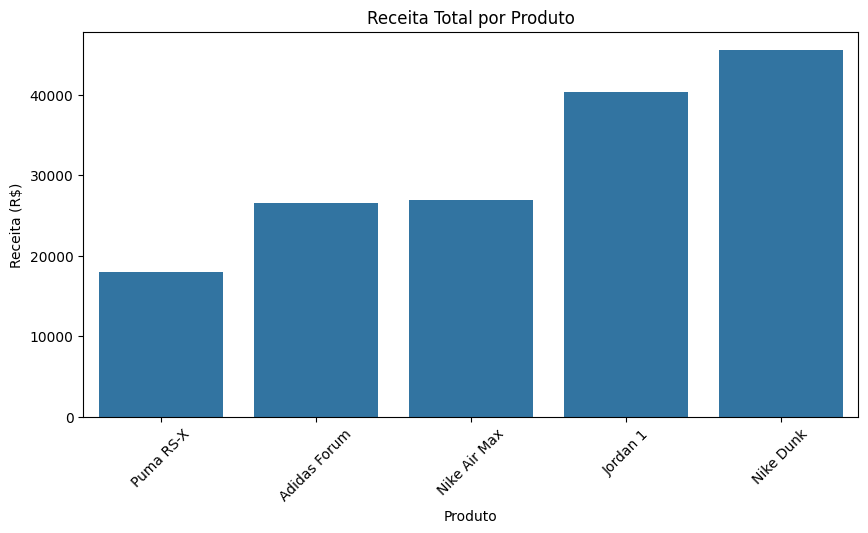

In [8]:
plt.figure(figsize=(10,5))

receita_produto = df.groupby('Produto')['Receita'].sum().sort_values()

sns.barplot(
    x=receita_produto.index,
    y=receita_produto.values
)

plt.title('Receita Total por Produto')
plt.xlabel('Produto')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)

plt.show()

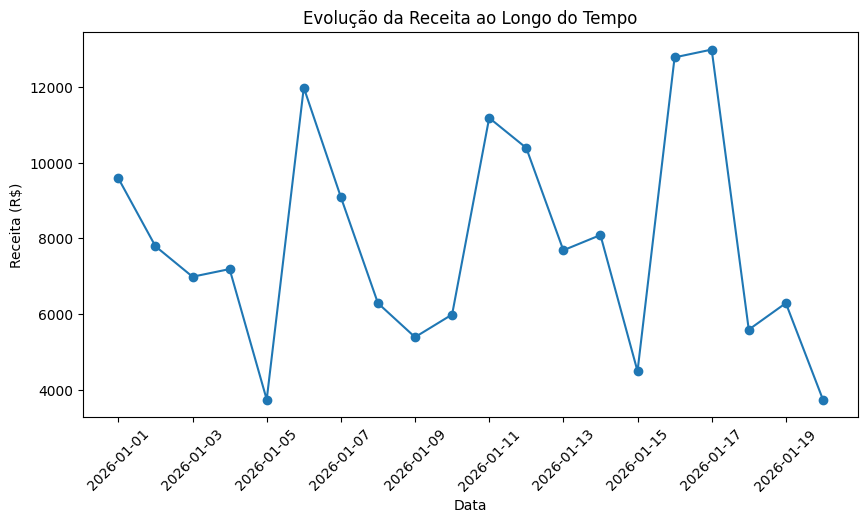

In [9]:
plt.figure(figsize=(10,5))

receita_data = df.groupby('Data')['Receita'].sum()

plt.plot(
    receita_data.index,
    receita_data.values,
    marker='o'
)

plt.title('Evolução da Receita ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)

plt.show()

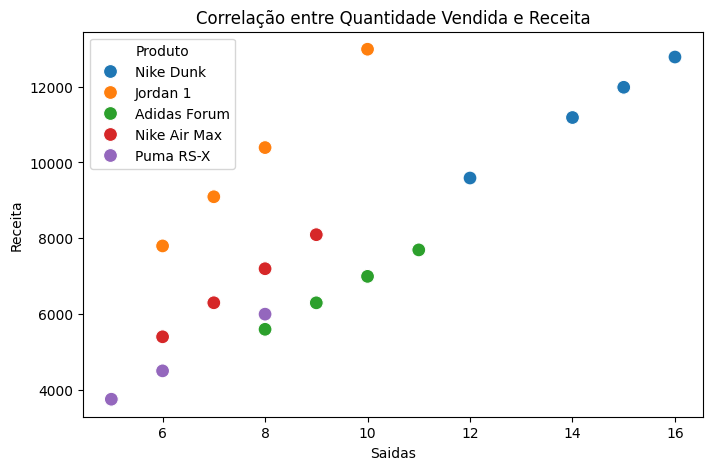

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Saidas',
    y='Receita',
    hue='Produto',
    s=100
)

plt.title('Correlação entre Quantidade Vendida e Receita')

plt.show()

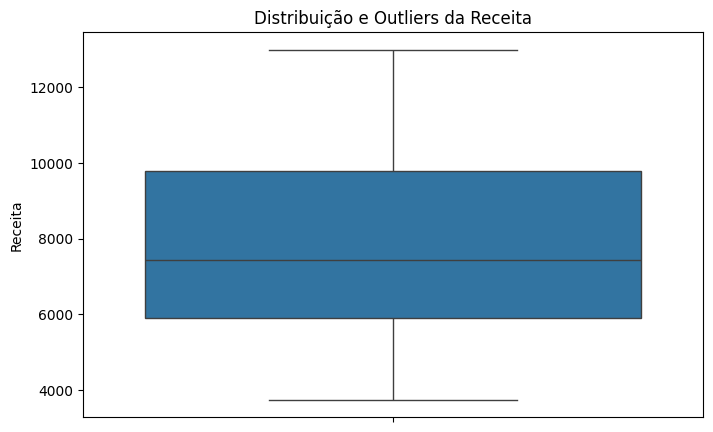

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Receita']
)

plt.title('Distribuição e Outliers da Receita')

plt.show()

## 2.5 Análise Crítica Exigida (Conexão com Etapa 1)

### Análise Crítica dos Resultados

Com base nos KPIs, estatísticas e visualizações geradas, foi identificado que o principal gargalo operacional da empresa está no controle e planejamento de estoque.

Os dados demonstraram que 9 registros apresentaram estoque abaixo do nível mínimo definido, indicando risco recorrente de ruptura de estoque e possível perda de vendas.

Além disso, o gráfico de receita por produto evidenciou forte concentração de faturamento em poucos itens, com destaque para Nike Dunk e Jordan 1, aumentando a criticidade do monitoramento desses produtos.

A correlação de 0,79 entre quantidade vendida e receita confirmou relação direta entre volume de vendas e faturamento, reforçando que indisponibilidade de estoque impacta significativamente o desempenho financeiro.

O Boxplot demonstrou ausência de outliers extremos, indicando que o problema operacional não está em vendas atípicas, mas sim em falhas estruturais de reposição e planejamento.

Esses resultados justificam integralmente o escopo definido no TAP da Disciplina 1, onde foi proposta a criação de um sistema inteligente de controle de estoque e dashboard analítico para suporte à tomada de decisão.